In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv('data/gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
x = df.drop(columns=['Calories_Burned'])
y=df['Calories_Burned']
x.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,Strength,29.2,2.8,3,1,14.39


In [5]:
y

0      1313.0
1       883.0
2       677.0
3       532.0
4       556.0
        ...  
968    1364.0
969    1260.0
970     929.0
971     883.0
972     542.0
Name: Calories_Burned, Length: 973, dtype: float64

In [6]:
numerical_features = df.select_dtypes(exclude="str").columns
categorical_features = df.select_dtypes(include="str").columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI'],
      dtype='str')

Categorical Features:
Index(['Gender', 'Workout_Type'], dtype='str')


In [7]:
for col in categorical_features:
    print(f"Categories in '{col}' variable:")
    print(df[col].unique())
    print()

Categories in 'Gender' variable:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Categories in 'Workout_Type' variable:
<StringArray>
['Yoga', 'HIIT', 'Cardio', 'Strength']
Length: 4, dtype: str



In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()

oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

C:\Users\pranj\AppData\Local\Temp\ipykernel_13276\1029257067.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include="object").columns


In [12]:
x = preprocessor.fit_transform(x)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((778, 18), (195, 18))

In [14]:
def evaluate_model(true, predicted):

    mae = mean_absolute_error(true, predicted)

    mse = mean_squared_error(true, predicted)

    rmse = np.sqrt(mean_squared_error(true, predicted))

    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [16]:
models = {

    "Linear Regression": LinearRegression(),

    "Lasso": Lasso(),

    "Ridge": Ridge(),

    "K-Neighbors Regressor": KNeighborsRegressor(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest Regressor": RandomForestRegressor(),

    "Gradient Boosting": GradientBoostingRegressor(),

    "XGBRegressor": XGBRegressor(),

    "CatBoosting Regressor": CatBoostRegressor(verbose=False),

    "AdaBoost Regressor": AdaBoostRegressor()
}

In [17]:
model_list = []
r2_list = []

for i in range(len(list(models))):

    model = list(models.values())[i]

    model.fit(X_train, y_train)

    # Predictions

    y_train_pred = model.predict(X_train)

    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test dataset

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train,
        y_train_pred
    )

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test,
        y_test_pred
    )

    print(list(models.keys())[i])

    model_list.append(list(models.keys())[i])

    r2_list.append(model_test_r2)

    print('Model performance for Training set')

    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))

    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))

    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')

    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))

    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))

    print("- R2 Score: {:.4f}".format(model_test_r2))

    print('='*35)

    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 38.9509
- Mean Absolute Error: 29.5598
- R2 Score: 0.9789
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 40.5731
- Mean Absolute Error: 30.2701
- R2 Score: 0.9803


Lasso
Model performance for Training set
- Root Mean Squared Error: 39.3280
- Mean Absolute Error: 29.6286
- R2 Score: 0.9785
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 40.6874
- Mean Absolute Error: 30.0256
- R2 Score: 0.9802


Ridge
Model performance for Training set
- Root Mean Squared Error: 38.9576
- Mean Absolute Error: 29.5481
- R2 Score: 0.9789
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 40.6454
- Mean Absolute Error: 30.3468
- R2 Score: 0.9802


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 90.3194
- Mean Absolute Error: 71.8409
- R2 Score: 0.8866
---------

In [18]:
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2 Score']
).sort_values(by=["R2 Score"], ascending=False)

,Model Name,R2 Score
8,CatBoosting Regressor,0.996921
6,Gradient Boosting,0.994369
7,XGBRegressor,0.980731
0,Linear Regression,0.980268
2,Ridge,0.980197
1,Lasso,0.980156
5,Random Forest Regressor,0.971709
4,Decision Tree,0.941208
9,AdaBoost Regressor,0.939528
3,K-Neighbors Regressor,0.827987


In [19]:
final_model = GradientBoostingRegressor()

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.9943907044478428


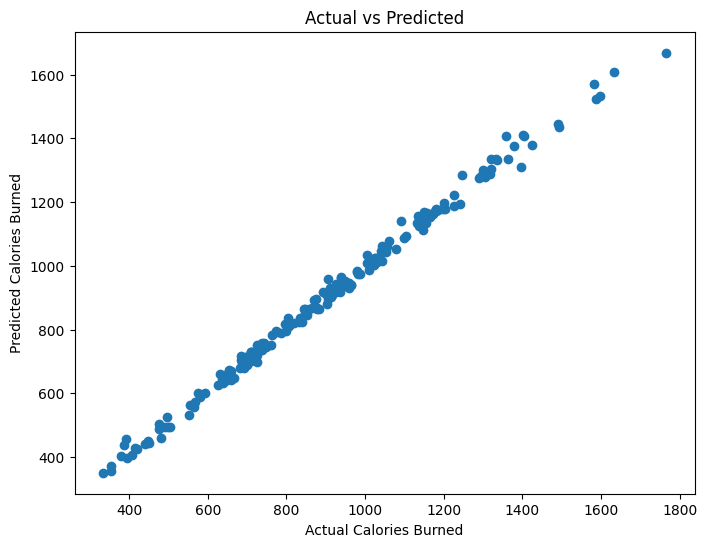

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Calories Burned")

plt.ylabel("Predicted Calories Burned")

plt.title("Actual vs Predicted")

plt.show()